# Signal Processing of Euler Disk

In [1]:
import os

import numpy as np
import euler_disk as ed
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import (
    welch,
    spectrogram,
    firwin,
    lfilter,
    hilbert,
    butter,
    filtfilt,
    resample_poly,
    windows,
)

## Configuration

In [ ]:
t0=16.20 # Change this depending of the actual sample
tmin=t0-2.0
tmax=t0+0.5

## Load your sample

In [ ]:
input_dir = "../data/wav/recording_11.wav"  # Change this
output_dir = "../data/output/recording_11/"
os.makedirs(output_dir, exist_ok=True)

fs, x = wavfile.read(input_dir)

if x.ndim > 1:
    x = x[:, 0]

x = np.asarray(x, dtype=np.float32)

N_target = int(3e6)

if len(x) < N_target:
    x = np.pad(x, (0, N_target - len(x)))

x += np.random.randn(len(x)) * 1e-3

N = len(x)
t = np.arange(N) / fs

## Step 1: Power Spectral Density
We then select and appropiate band pass for step 3.

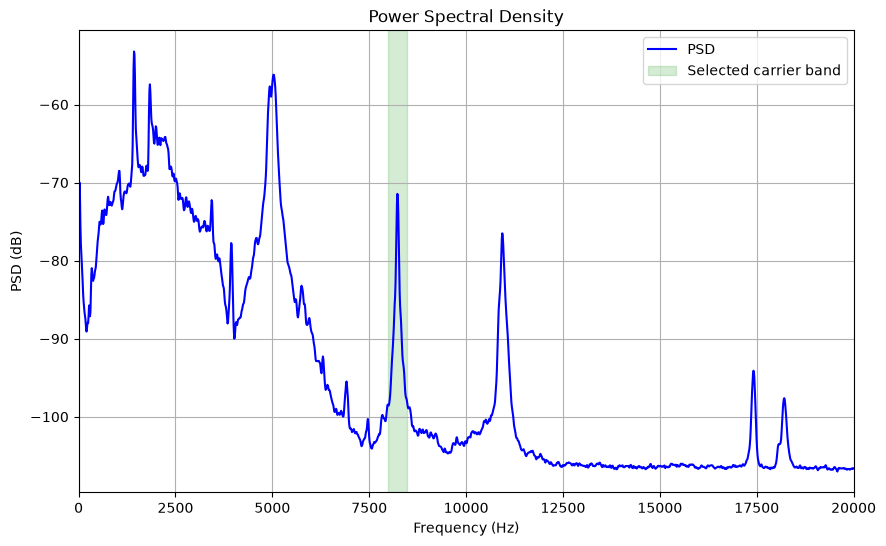

In [4]:
fmax = 20000

frequency, power = welch(
    x,
    fs=fs,
    window="hamming",
    nperseg=4096,
    noverlap=2048,
    nfft=8192,
)

band = (frequency <= fmax)
frequency = frequency[band]
power = power[band]

np.savez_compressed(
    f"{output_dir}/data_welch.npz", frequencies=frequency, power=power
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    frequency,
    10 * np.log10(power),
    color="b",
    lw=1.5,
    label="PSD",
)

ax.axvspan(
    8226 - 250,
    8226 + 250,
    color="tab:green",
    alpha=0.2,
    label="Selected carrier band",
)

ax.set(
    xlabel="Frequency (Hz)",
    ylabel="PSD (dB)",
    xlim=(0, fmax),
    title="Power Spectral Density",
)

ax.grid(True)
ax.legend()

In [5]:
peaks = ed.peaks(
    input_path=f"{output_dir}/data_welch.npz",
    output_dir=f"{output_dir}",
    prominence=6,   # dB
    distance=2,     # bins (~47 Hz at Δf≈23.4 Hz)
)

data_welch = np.load(f"{output_dir}/data_welch.npz")

n = len(peaks["frequencies"])
print(f"\nFound {n} peaks:\n")
print(f"{'Frequency (Hz)':<18} {'Power (V²/Hz)':<18} {'Prominence (dB)':<18}")
print("-" * 54)

freqs = peaks["frequencies"]
powers = peaks["powers"]
proms = peaks.get("prominences", [None] * n)

for f, p, pr in zip(freqs, powers, proms):
    prom_str = f"{pr:<18.2f}" if pr is not None else f"{'—':<18}"
    print(f"{f:<18.2f} {p:<18.3e} {prom_str}")

peak_data = np.load(f"{output_dir}/peak_data.npz")

welch_db = 10 * np.log10(data_welch["power"] + 1e-20)
peak_db = 10 * np.log10(peak_data["powers"] + 1e-20)


Found 9 peaks:

Frequency (Hz)     Power (V²/Hz)      Prominence (dB)   
------------------------------------------------------
23.44              9.993e-08          7.90              
1429.69            4.777e-06          35.88             
1839.84            1.812e-06          11.71             
3937.50            1.677e-08          10.30             
5027.34            2.411e-06          33.82             
8226.56            7.167e-08          32.64             
10933.59           2.237e-08          28.20             
17414.06           3.882e-10          12.63             
18210.94           1.728e-10          9.10              


## Step 2: Spectogram

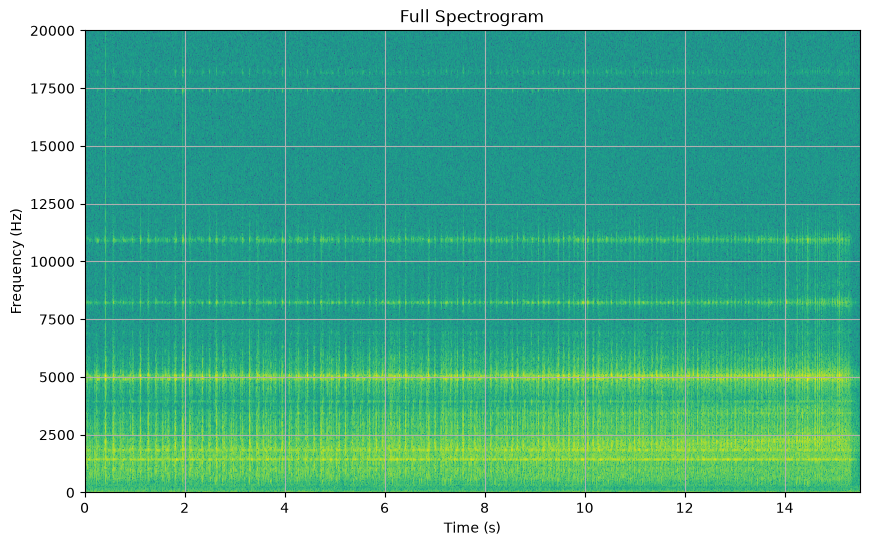

In [6]:
f, ts, S = spectrogram(
    x,
    fs=fs,
    window="hamming",
    nperseg=2048,
    noverlap=1024,
    nfft=4096,
    detrend=False,
    scaling="spectrum",
    mode="complex",
)

fig, ax = plt.subplots(figsize=(10, 6), sharex=True)
ax.pcolormesh(ts, f, 10 * np.log10(np.abs(S) + 1e-12), shading="auto")
ax.set(xlabel="Time (s)", ylabel="Frequency (Hz)", xlim=(0, tmax), ylim=(0, fmax), title="Full Spectrogram")
ax.grid(True)

fig.savefig(
    os.path.join(output_dir, "spectogram.png"),
    dpi=300,
    bbox_inches="tight",
)

## Step 3: Bandpass and Downsample

In [7]:
carrier_peak = 8226

bandwidth = 500

lower_cutoff = carrier_peak - bandwidth/2
upper_cutoff = carrier_peak + bandwidth/2

In [8]:
B = firwin(
    401,
    [lower_cutoff, upper_cutoff],
    pass_zero=False,
    fs=fs,
)

y = lfilter(B, [1.0], x)  # Filter the signal

a0 = np.abs(hilbert(y))  # Envelope of the filtered signal

In [9]:
a1 = resample_poly(a0, up=1, down=100)

fs_env = fs / 100

bhp, ahp = butter(2, 3 / (fs_env / 2), btype="high")

a2 = lfilter(bhp, ahp, a1)

f_env, ts_env, A0 = spectrogram(
    a2,
    fs=fs_env,
    window="hamming",
    nperseg=512,
    noverlap=500,
    nfft=4096,
    detrend=False,
    scaling="spectrum",
    mode="complex",
)

np.savez_compressed(
    f"{output_dir}/envelope_spectrogram.npz",
    f=f_env,
    t=ts_env,
    A=A0,
)

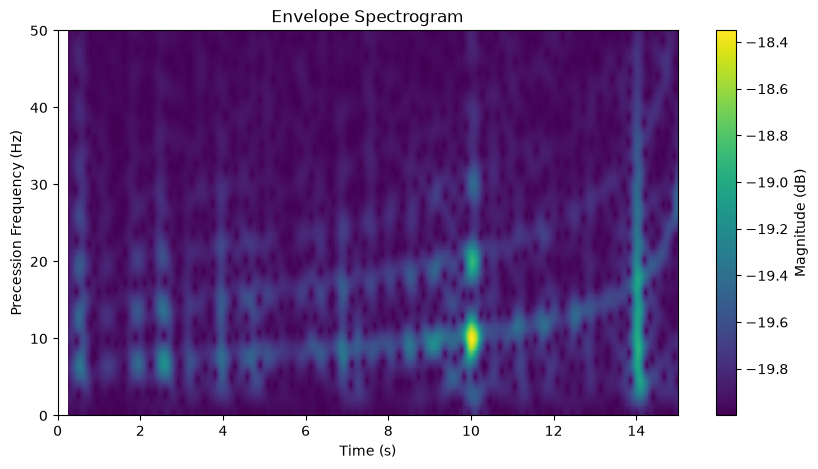

In [10]:
data = np.load(f"{output_dir}/envelope_spectrogram.npz")

f_env = data["f"]
ts_env = data["t"]
A0 = data["A"]

fig, ax = plt.subplots(figsize=(10,5))

spectrogram_db = 10 * np.log10(np.abs(A0) + 0.01)

mesh = ax.pcolormesh(
    ts_env,
    f_env,
    spectrogram_db,
    shading="auto",
    cmap="viridis",

)
ax.set(
    xlabel="Time (s)",
    ylabel="Precession Frequency (Hz)",
    title="Envelope Spectrogram",
    xlim=(0, t0),
    ylim=(0,50),
)

fig.colorbar(mesh,label="Magnitude (dB)")

fig.savefig(
    os.path.join(output_dir, "envelope_spectrogram.png"),
    dpi=300,
    bbox_inches="tight",
)

## Step 5: Extract Dominant Precession Ridge

In [11]:
ridge_tracking = "neighbor"      # "global" or "neighbor"
search_width = 4               # only used for neighbor tracking

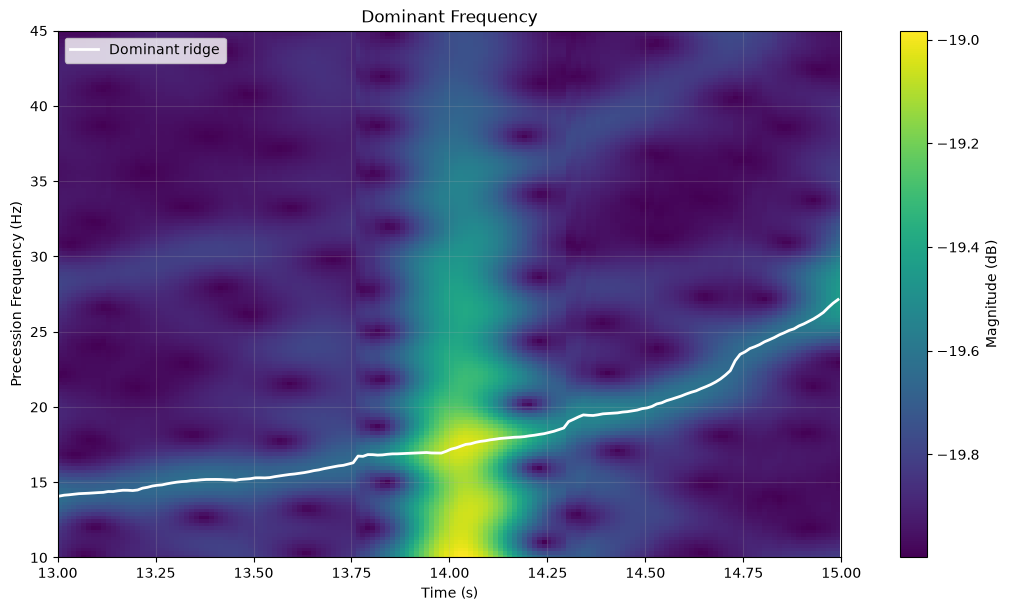

In [12]:
spectrogram_power = np.abs(A0) ** 2

# -------------------------------------------------------
# Ridge extraction
# -------------------------------------------------------

if ridge_tracking == "global":

    idx = np.argmax(spectrogram_power, axis=0)

elif ridge_tracking == "neighbor":

    idx = np.zeros(spectrogram_power.shape[1], dtype=int)

    # Initialize with the global maximum
    idx[0] = np.argmax(spectrogram_power[:, 0])

    for k in range(1, spectrogram_power.shape[1]):

        i0 = idx[k - 1]

        i_min = max(0, i0 - search_width)
        i_max = min(len(f_env), i0 + search_width + 1)

        idx[k] = i_min + np.argmax(
            spectrogram_power[i_min:i_max, k]
        )

else:
    raise ValueError(
        "ridge_tracking must be 'global' or 'neighbor'"
    )


# -------------------------------------------------------
# Quadratic interpolation
# -------------------------------------------------------

Pm = spectrogram_power[idx, np.arange(len(idx))]

fmax = f_env[idx]
fmax_smooth = fmax.copy()

df = f_env[1] - f_env[0]

for k in range(len(idx)):

    i = idx[k]

    if 0 < i < len(f_env) - 1:

        ya = spectrogram_power[i - 1, k] - Pm[k]
        yb = spectrogram_power[i + 1, k] - Pm[k]

        dx = (ya - yb) / (ya + yb) * 0.5

        fmax_smooth[k] += dx * df
        
# -------------------------------------------------------
# Plot ridge over the envelope spectrogram
# -------------------------------------------------------

time_mask = (ts_env >= tmin) & (ts_env <= t0)
freq_mask = (f_env >= 10) & (f_env <= 45)

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

mesh = ax.pcolormesh(
    ts_env[time_mask],
    f_env[freq_mask],
    spectrogram_db[np.ix_(freq_mask, time_mask)],
    shading="auto",
    cmap="viridis",
)

ax.plot(
    ts_env[time_mask],
    fmax_smooth[time_mask],
    color="white",
    linewidth=2,
    label="Dominant ridge",
)

ax.set(
    xlabel="Time (s)",
    ylabel="Precession Frequency (Hz)",
    title="Dominant Frequency",
    xlim=(tmin, t0),
    ylim=(10, 45),
)

ax.grid(True, which="both", alpha=0.2)
ax.legend(loc="upper left")

cbar = fig.colorbar(mesh, ax=ax)
cbar.set_label("Magnitude (dB)")

plt.show()

fig.savefig(
    os.path.join(output_dir, "dominant_frequency.png"),
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    os.path.join(output_dir, "dominant_frequency.pdf"),
    bbox_inches="tight",
)

## Step 6: Power Fit

Full Fit: alpha = 0.28224
Last 4s: alpha = 0.22164
Last 1s: alpha = 0.13114


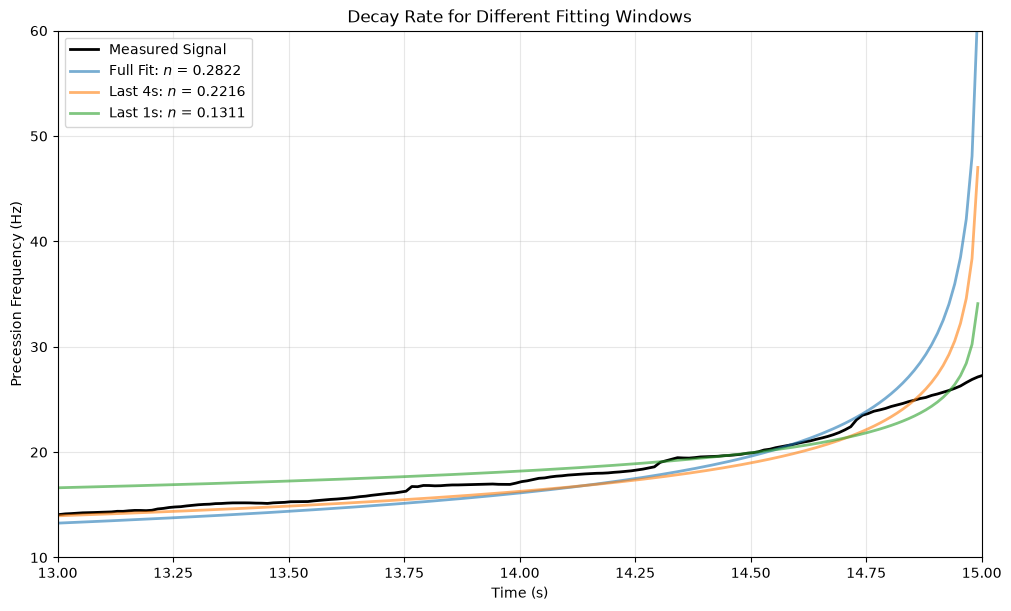

In [13]:
t_clean = 5  # Time after which the signal is considered clean for fitting

fit_windows = {
    "Full Fit": t0 - t_clean,
    "Last 4s": 4.0,
    "Last 1s": 1.0,
}

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

ax.plot(
    ts_env,
    fmax_smooth,
    color="black",
    linewidth=2,
    label="Measured Signal",
)

colors = ["tab:blue", "tab:orange", "tab:green"]

for color, (label, window) in zip(colors, fit_windows.items()):

    if window is None:
        fit_mask = ts_env < t0
    else:
        fit_mask = (ts_env >= t0 - window) & (ts_env < t0)

    xfit = np.log10(t0 - ts_env[fit_mask])
    yfit = np.log10(fmax_smooth[fit_mask])

    slope, intercept = np.polyfit(xfit, yfit, 1)

    alpha = -slope
    k = 10 ** intercept

    print(f"{label:>5}: alpha = {alpha:.5f}")

    model = np.full_like(ts_env, np.nan)

    pre_mask = ts_env < t0
    model[pre_mask] = k * (1 / (t0 - ts_env[pre_mask])) ** alpha

    ax.plot(
        ts_env,
        model,
        color=color,
        linewidth=2,
        label=f"{label}: $n$ = {alpha:.4f}",
        alpha=0.6,
    )

ax.set(
    xlabel="Time (s)",
    ylabel="Precession Frequency (Hz)",
    title="Decay Rate for Different Fitting Windows",
    xlim=(tmin, t0),
    ylim=(10, 60),
)

ax.grid(True, alpha=0.3)
ax.legend()

fig.savefig(
    os.path.join(output_dir, "decay_rates.png"),
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    os.path.join(output_dir, "decay_rates.pdf"),
    bbox_inches="tight",
)

## Analytic results

### Medium Disk - Granite
All Measurements:

| Measurement | Full Fit (n) | Last 4 s (n) | Last 1 s (n) | Notes |
| :---------: | ------------------: | ------------------: | ------------------: | :---- |
|      1      |             0.30456 |             0.11547 |             0.04692 |       |
|      2      |             0.28188 |             0.17100 |             0.07358 |       |
|      3      |             0.29179 |             0.16608 |             0.08466 |       |
|      4      |             0.35000 |             0.25847 |             0.18769 | Best  |
|      5      |             0.33254 |             0.22291 |             0.12934 | Good  |
|      6      |             0.29490 |             0.17807 |             0.08560 |       |
|      7      |             0.32876 |             0.22069 |             0.11466 | Good  |
|      8      |             0.29895 |             0.20654 |             0.10950 | OK    |
|      9      |             0.32013 |             0.24068 |             0.11771 |       |
|      10     |             0.30281 |             0.17505 |             0.06875 |       |
|      11     |             0.26529 |             0.24102 |             0.09424 |       |
|      12     |             0.28224 |             0.22163 |             0.13114 |       |
|      13     |             0.34151 |             0.34109 |             0.19677 | Bad   |
|      14     |             0.26199 |             0.20540 |             0.09415 | Bad   |
|      15     |             0.30051 |             0.24221 |             0.14357 |       |